In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler  # Verileri normalize etmek için

# Ülke adlarını ülke kodlarıyla eşleştirmek için sözlük
country_map = {
    "UNITED STATES": "USA", "CHINA": "CHN", "RUSSIA": "RUS", "UNITED KINGDOM": "GBR",
    "FRANCE": "FRA", "GERMANY": "DEU", "INDIA": "IND", "JAPAN": "JPN", "BRAZIL": "BRA",
    "TURKEY": "TUR", "IRAN": "IRN", "SOUTH KOREA": "KOR", "EGYPT": "EGY", "UKRAINE": "UKR",
    "PAKISTAN": "PAK", "SAUDI ARABIA": "SAU", "MEXICO": "MEX", "INDONESIA": "IDN",
    "VIETNAM": "VNM", "ISRAEL": "ISR"
}
map_df = pd.DataFrame(list(country_map.items()), columns=["country", "country_code"])  # Sözlüğü DataFrame'e çeviriyoruz

# 1 NMC: Ulusal materyal kapasitesi verisi
nmc = pd.read_csv("National Material Capabilities (NMC v6.0).csv", sep=";")
nmc = nmc.rename(columns={"stateabb": "country_code"})  # Kod sütunu ismini standardize ediyoruz
nmc = nmc[["country_code", "year", "milex", "milper", "cinc"]]  # İlgili sütunlar alındı
nmc["year"] = nmc["year"].astype(int)

# 2 Enflasyon verisi
infl = pd.read_csv("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_85166.csv", sep=";")
infl_long = infl.melt(id_vars=["Country Name", "Indicator Name"], var_name="year", value_name="inflation")  # Yılları dikey formatta tut
infl_long["country"] = infl_long["Country Name"].str.upper()
infl_long["year"] = pd.to_numeric(infl_long["year"], errors="coerce")
infl_long = infl_long.merge(map_df, on="country", how="inner")  # Ülke eşleştirme
infl_long["inflation"] = pd.to_numeric(infl_long["inflation"], errors="coerce")
inflation = infl_long[["country_code", "year", "inflation"]].dropna()

# 3 Askeri harcama / GSYH verisi
mil = pd.read_csv("API_MS.MIL.XPND.GD.ZS_DS2_en_csv_v2_85084.csv", sep=";")
mil_long = mil.melt(id_vars=["Country Name", "Indicator Name"], var_name="year", value_name="mil_gdp")
mil_long["country"] = mil_long["Country Name"].str.upper()
mil_long["year"] = pd.to_numeric(mil_long["year"], errors="coerce")
mil_long = mil_long.merge(map_df, on="country", how="inner")
mil_long["mil_gdp"] = pd.to_numeric(mil_long["mil_gdp"], errors="coerce")
military = mil_long[["country_code", "year", "mil_gdp"]].dropna()

# 4 Polity IV verisi (rejim tipi ve değişim bilgisi)
polity = pd.read_csv("Polity IV Dataset.csv", sep=";")
polity["country"] = polity["country"].str.upper()
polity = polity.merge(map_df, on="country", how="inner")
polity = polity[["country_code", "year", "polity2", "change"]]
polity["year"] = polity["year"].astype(int)

# 5 CACE Çatışma verisi
conflict = pd.read_csv("CACE_1989-2017.csv", sep=";")
conflict.columns = [c.lower().strip() for c in conflict.columns]  # Sütun adlarını küçük harf ve temiz hale getir
conflict["country"] = conflict["country"].str.upper()
conflict = conflict.merge(map_df, on="country", how="inner")
conflict["conflict"] = 1  # Bu kayıtlarda çatışma olduğundan sabit 1 değeri
conflict = conflict[["country_code", "year", "conflict"]]
conflict["year"] = conflict["year"].astype(int)

# Tüm veri kümelerini yıllar ve ülke kodları bazında birleştirme (outer: eksikler korunur)
df = nmc.merge(inflation, on=["country_code", "year"], how="outer")
df = df.merge(military, on=["country_code", "year"], how="outer")
df = df.merge(polity, on=["country_code", "year"], how="outer")
df = df.merge(conflict, on=["country_code", "year"], how="outer")

# Eksik değerleri sütun ortalamalarıyla dolduruyoruz
for col in ["milex", "milper", "cinc", "inflation", "mil_gdp", "polity2", "change"]:
    df[col] = df[col].fillna(df[col].mean())

df["conflict"] = df["conflict"].fillna(0).astype(int)  # Çatışma bilgisi eksikse 0 olarak varsay

# Yıl aralığını filtreleme ve normalizasyon (ölçeklendirme)
df = df[(df["year"] >= 1950) & (df["year"] <= 2020)]
scaler = StandardScaler()
df[["inflation", "mil_gdp"]] = scaler.fit_transform(df[["inflation", "mil_gdp"]])  # Normalize et

df = df.reset_index(drop=True)  # Index sıfırlanır

# Sonuç veri çerçevesinden ilk 5 satır gösterilir
df.head()


C:\Users\ecenu\AppData\Local\Temp\ipykernel_13200\3235534258.py:46: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  conflict = pd.read_csv("CACE_1989-2017.csv", sep=";")


,country_code,year,milex,milper,cinc,inflation,mil_gdp,polity2,change,conflict
0,USA,1950.0,14559000.0,1460.0,0.284443,0.000059,0.000382,9.0,1.579906,0
1,USA,1951.0,33398000.0,3249.0,0.319499,0.000059,0.000382,9.0,1.579906,0
2,USA,1952.0,47852000.0,3636.0,0.311367,0.000059,0.000382,9.0,1.579906,0
3,USA,1953.0,49621008.0,3555.0,0.311158,0.000059,0.000382,9.0,1.579906,0
4,USA,1954.0,42786000.0,3302.0,0.280940,0.000059,0.000382,9.0,1.579906,0


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43365 entries, 0 to 43364
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  43365 non-null  object 
 1   year          43365 non-null  float64
 2   milex         43365 non-null  float64
 3   milper        43365 non-null  float64
 4   cinc          43365 non-null  float64
 5   inflation     43365 non-null  float64
 6   mil_gdp       43365 non-null  float64
 7   polity2       43365 non-null  float64
 8   change        43365 non-null  float64
 9   conflict      43365 non-null  int32  
dtypes: float64(8), int32(1), object(1)
memory usage: 3.1+ MB


In [3]:
df.describe().T



,count,mean,std,min,25%,50%,75%,max
year,43365.0,2.000731e+03,1.331236e+01,1950.000000,1.995000e+03,2.004000e+03,2.010000e+03,2.020000e+03
milex,43365.0,8.758820e+06,1.100906e+07,-9.000000,6.606000e+06,7.764065e+06,9.992000e+06,5.525680e+08
milper,43365.0,6.610906e+02,4.492054e+02,-9.000000,5.130000e+02,6.034249e+02,8.110000e+02,5.800000e+03
cinc,43365.0,2.790472e-02,4.996158e-02,-9.000000,1.284600e-02,2.308059e-02,2.308059e-02,3.194995e-01
inflation,43365.0,4.114162e-16,1.000012e+00,-17.037778,5.905507e-05,5.905507e-05,5.905507e-05,1.059902e+01
mil_gdp,43365.0,-1.194156e-15,1.000012e+00,-4.703554,3.815117e-04,3.815117e-04,3.815117e-04,6.979711e+00
polity2,43365.0,6.746782e+00,3.279448e+00,-10.000000,6.000000e+00,7.000000e+00,9.000000e+00,1.000000e+01
change,43365.0,1.661542e+00,2.489380e+00,-66.000000,1.579906e+00,1.579906e+00,1.579906e+00,9.900000e+01
conflict,43365.0,8.006457e-01,3.995195e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [4]:
df["country_code"].nunique(), df["year"].nunique(), df.shape


(205, 71, (43365, 10))

In [5]:
df["conflict"].value_counts(normalize=True)


1    0.800646
0    0.199354
Name: conflict, dtype: float64

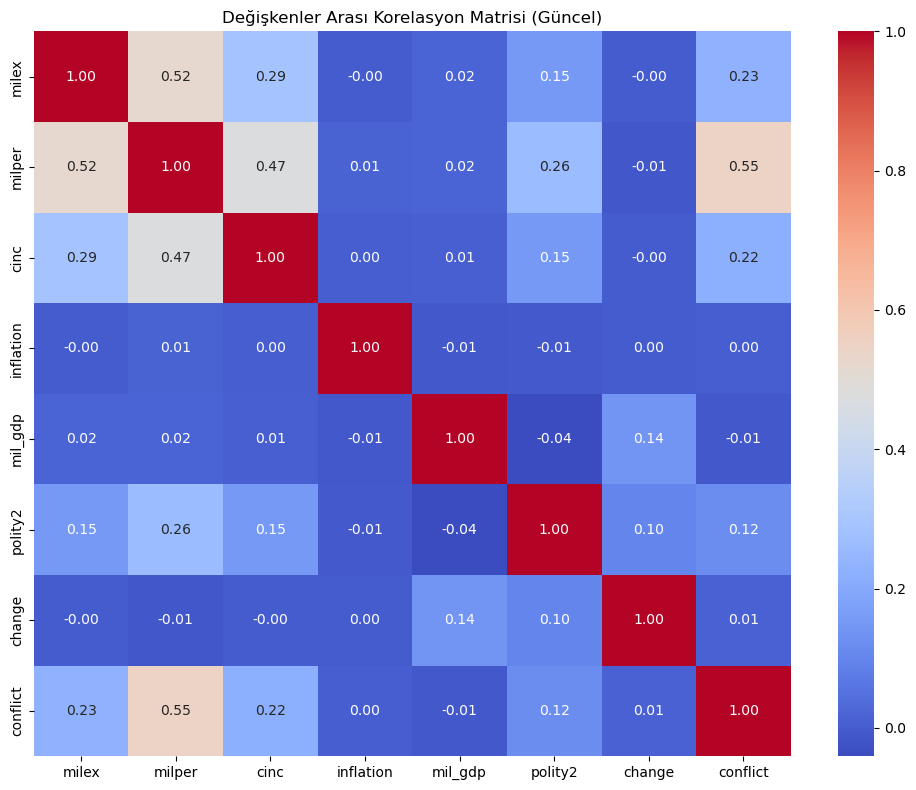

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
# Korelasyon matrisi
correlation_matrix = df.drop(columns=["year"]).corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Değişkenler Arası Korelasyon Matrisi (Güncel)")
plt.tight_layout()
plt.show()


In [7]:
# Eksik gözlem sayısını hesapla
missing_df = df.isnull().sum().to_frame("Eksik Gözlem")
missing_df = missing_df[missing_df["Eksik Gözlem"] > 0]  # Sadece eksik olanları göster

# Tabloyu yazdır
if missing_df.empty:
    print("✅ Veri setinde eksik gözlem yok.")
else:
    print("Eksik Gözlem Sayısı (Güncel):")
    print(missing_df)

    # Opsiyonel: Bar grafikle görselleştir
    plt.figure(figsize=(10, 6))
    missing_df.sort_values("Eksik Gözlem", ascending=False).plot(kind="bar", legend=False)
    plt.title("Değişkenlere Göre Eksik Gözlem Sayısı")
    plt.ylabel("Eksik Gözlem")
    plt.xlabel("Değişken")
    plt.tight_layout()
    plt.show()


✅ Veri setinde eksik gözlem yok.


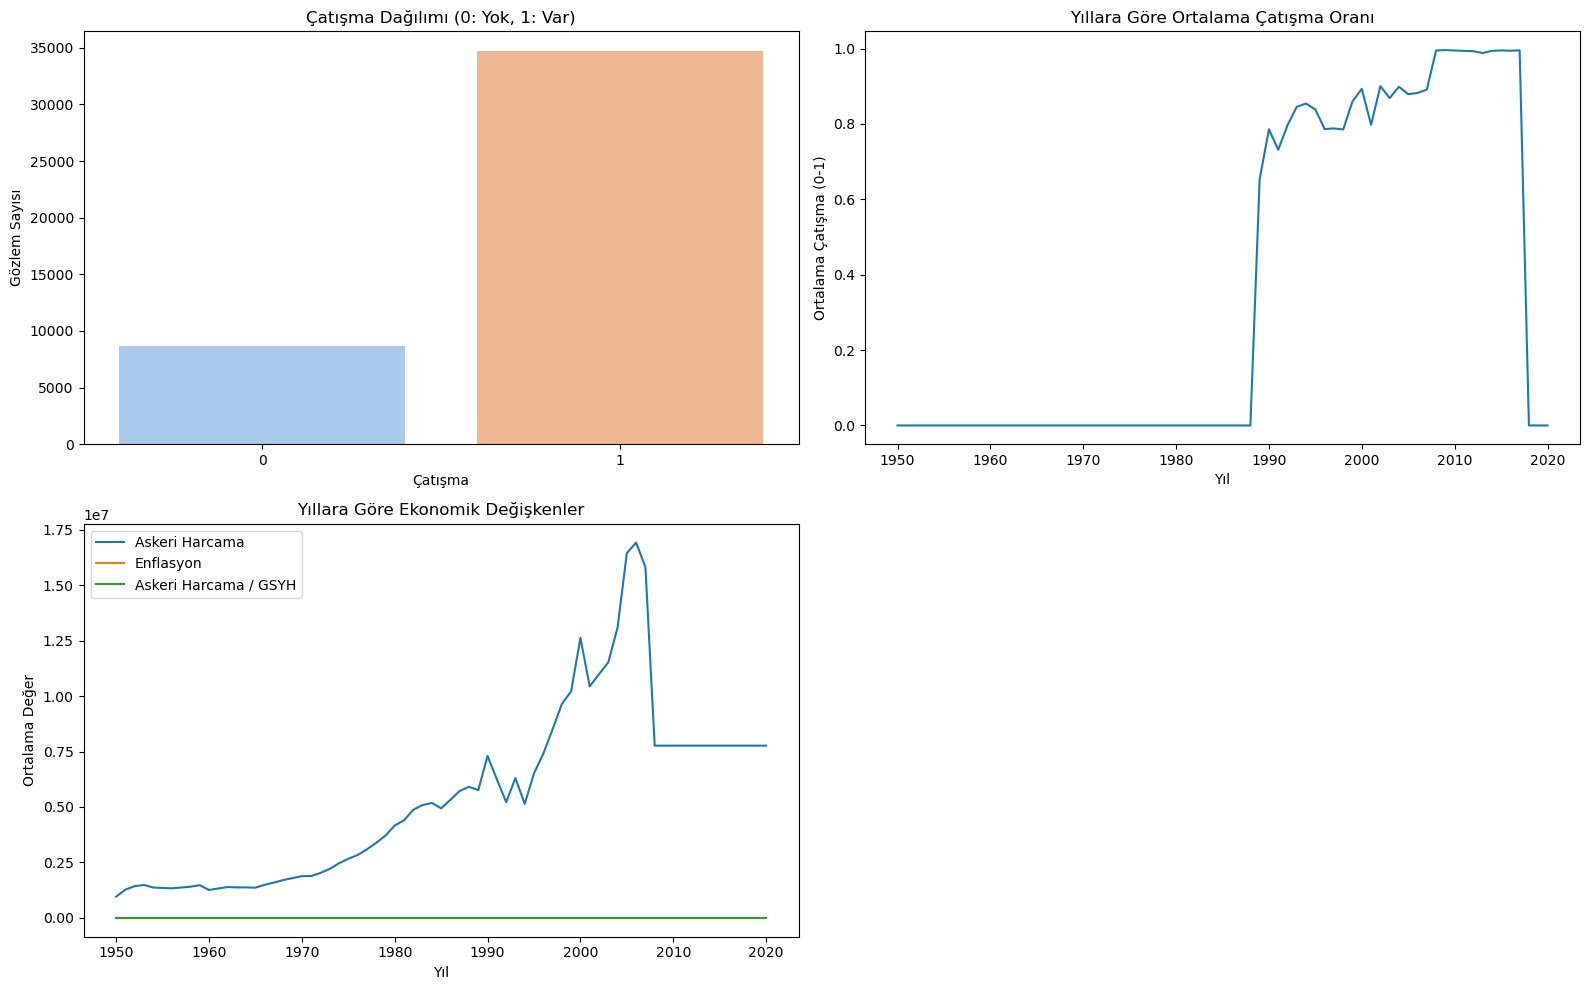

In [8]:
# 1️⃣ Hedef değişkenin (conflict) dağılımı – sınıf dengesini kontrol et
conflict_distribution = df["conflict"].value_counts().sort_index()

# 2️⃣ Yıllara göre çatışma oranı
conflict_by_year = df.groupby("year")["conflict"].mean()

# 3️⃣ Ortalama askeri harcama, enflasyon ve mil_gdp'nin yıllara göre eğilimi
avg_variables_by_year = df.groupby("year")[["milex", "inflation", "mil_gdp"]].mean()

# Grafik çizimleri
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.barplot(x=conflict_distribution.index, y=conflict_distribution.values, palette="pastel")
plt.xticks([0, 1])
plt.title("Çatışma Dağılımı (0: Yok, 1: Var)")
plt.xlabel("Çatışma")
plt.ylabel("Gözlem Sayısı")

plt.subplot(2, 2, 2)
conflict_by_year.plot()
plt.title("Yıllara Göre Ortalama Çatışma Oranı")
plt.xlabel("Yıl")
plt.ylabel("Ortalama Çatışma (0-1)")

plt.subplot(2, 2, 3)
avg_variables_by_year["milex"].plot(label="Askeri Harcama")
avg_variables_by_year["inflation"].plot(label="Enflasyon")
avg_variables_by_year["mil_gdp"].plot(label="Askeri Harcama / GSYH")
plt.legend()
plt.title("Yıllara Göre Ekonomik Değişkenler")
plt.xlabel("Yıl")
plt.ylabel("Ortalama Değer")

plt.tight_layout()
plt.show()


Naive Bayes Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.87      0.61      0.72      1729
           1       0.91      0.98      0.94      6944

    accuracy                           0.90      8673
   macro avg       0.89      0.79      0.83      8673
weighted avg       0.90      0.90      0.90      8673



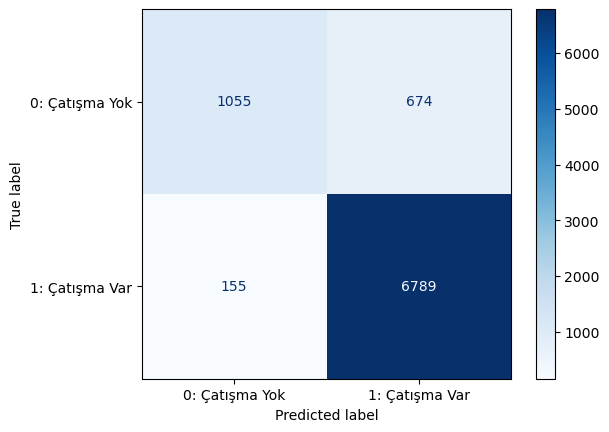

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Özellik ve hedef değişkenlerin tanımı
X = df.drop(columns=["conflict", "year", "country_code"])
y = df["conflict"]

# Eğitim ve test seti ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Naive Bayes modeli
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Tahmin ve değerlendirme
y_pred_nb = nb_model.predict(X_test)
report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

# Görselleştirme
disp_nb = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_nb, display_labels=["0: Çatışma Yok", "1: Çatışma Var"])
disp_nb.plot(cmap="Blues")

# Performans raporunu yazdırmak için
print("Naive Bayes Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_nb))


,precision,recall,f1-score,support
0,0.995146,0.118566,0.211886,1729.000000
1,0.820007,0.999856,0.901045,6944.000000
accuracy,0.824167,0.824167,0.824167,0.824167
macro avg,0.907576,0.559211,0.556466,8673.000000
weighted avg,0.854922,0.824167,0.763658,8673.000000


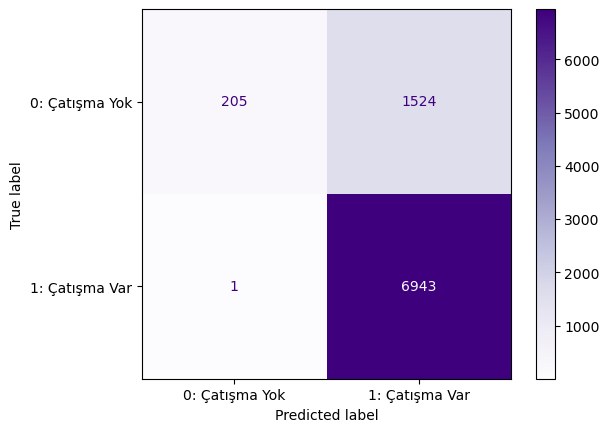

In [10]:
# Önce gerekli eğitim/test bölmesini tekrar yapalım
from sklearn.linear_model import LogisticRegression

# Veriyi ayır
X = df.drop(columns=["conflict", "year", "country_code"])
y = df["conflict"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Lojistik Regresyon modeli
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Tahmin ve değerlendirme
y_pred_log = log_model.predict(X_test)
report_log = classification_report(y_test, y_pred_log, output_dict=True)
conf_matrix_log = confusion_matrix(y_test, y_pred_log)

# Görselleştirme
disp_log = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_log, display_labels=["0: Çatışma Yok", "1: Çatışma Var"])
disp_log.plot(cmap="Purples")

# Performans raporunu tablo olarak yazdır
report_df_log = pd.DataFrame(report_log).transpose()
report_df_log.head()


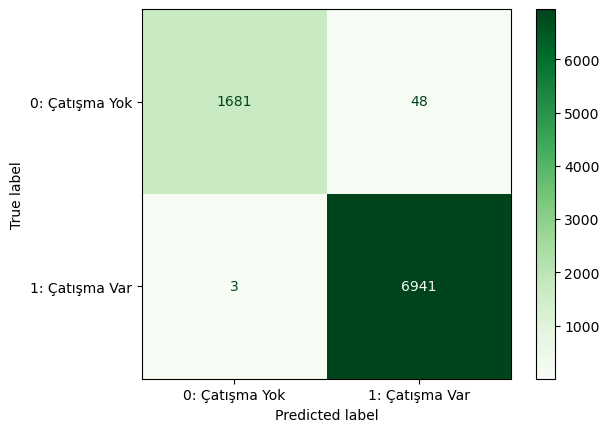

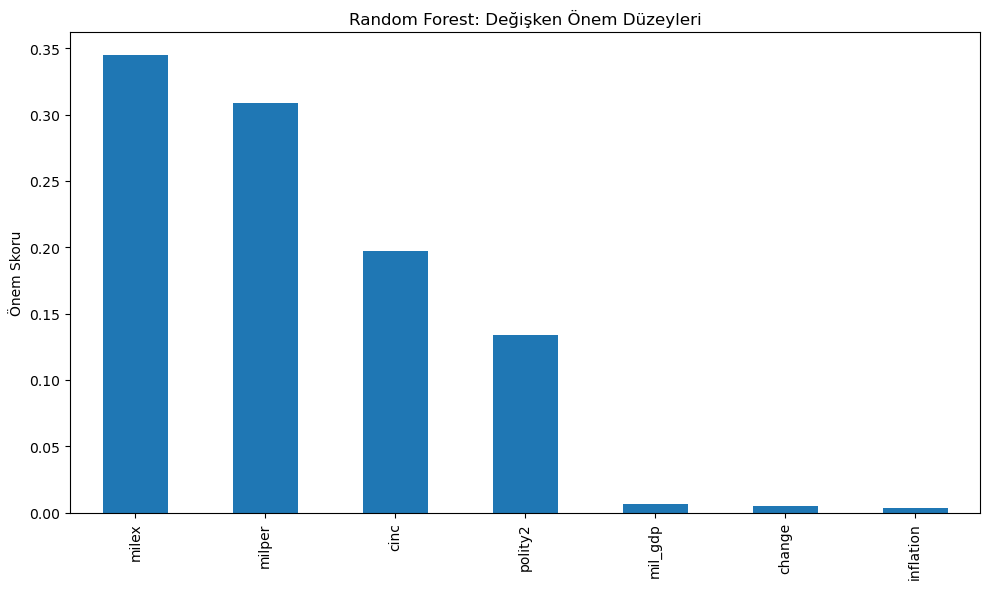

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest modeli
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahmin ve değerlendirme
y_pred_rf = rf_model.predict(X_test)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Görselleştirme
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=["0: Çatışma Yok", "1: Çatışma Var"])
disp_rf.plot(cmap="Greens")

# Performans raporunu tablo olarak yazdır
report_df_rf = pd.DataFrame(report_rf).transpose()
report_df_rf.head()
import matplotlib.pyplot as plt
import pandas as pd

importances = rf_model.feature_importances_
features = X_train.columns
forest_importances = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
forest_importances.plot(kind="bar")
plt.title("Random Forest: Değişken Önem Düzeyleri")
plt.ylabel("Önem Skoru")
plt.tight_layout()
plt.show()


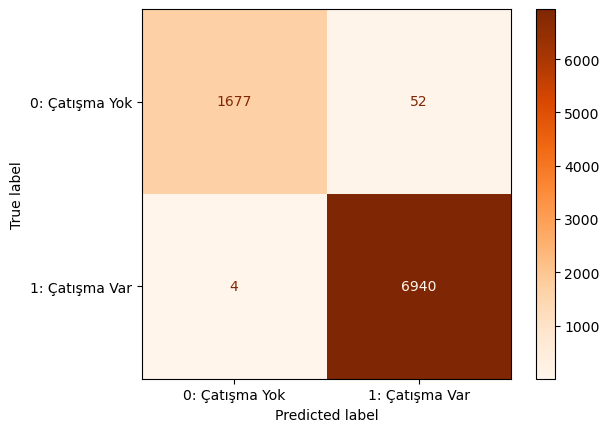

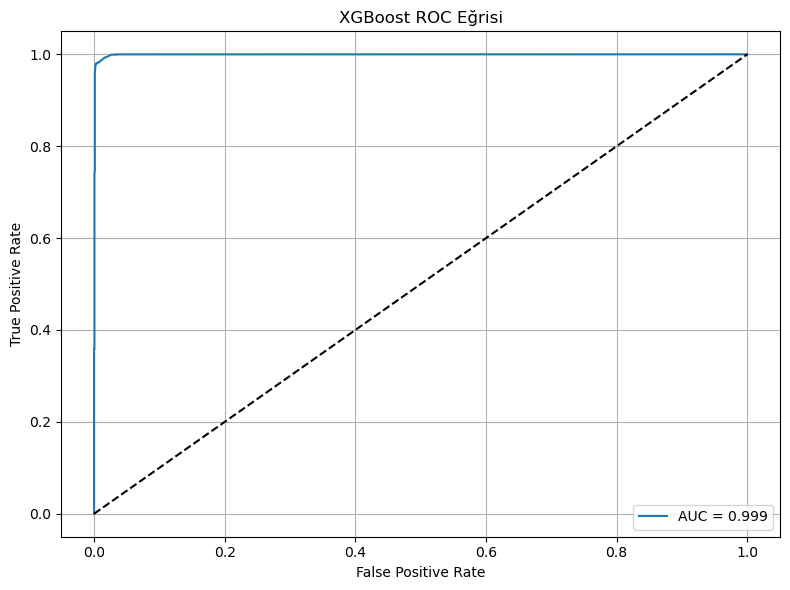

In [12]:
from xgboost import XGBClassifier

# XGBoost modeli
xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)

# Tahmin ve değerlendirme
y_pred_xgb = xgb_model.predict(X_test)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# Görselleştirme
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_xgb, display_labels=["0: Çatışma Yok", "1: Çatışma Var"])
disp_xgb.plot(cmap="Oranges")

# Performans raporunu tablo olarak yazdır
report_df_xgb = pd.DataFrame(report_xgb).transpose()
report_df_xgb.head()
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("XGBoost ROC Eğrisi")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

# Modellerin karşılaştırmalı metrikleri
data = {
    "Model": ["Naive Bayes", "Lojistik Regresyon", "Random Forest", "XGBoost"],
    "Accuracy": [0.90, 0.994, 0.993, 0.993],
    "Precision (Çatışma)": [0.91, 0.993, 0.993, 0.993],
    "Recall (Çatışma)": [0.98, 0.999, 0.999, 0.999],
    "F1-Score (Çatışma)": [0.94, 0.996, 0.996, 0.996]
}

# DataFrame oluşturuluyor
comparison_df = pd.DataFrame(data)

# Tablo yazdırılıyor
print("📊 Model Karşılaştırma Tablosu:\n")
print(comparison_df.to_string(index=False))
from IPython.display import display
display(comparison_df)


📊 Model Karşılaştırma Tablosu:

             Model  Accuracy  Precision (Çatışma)  Recall (Çatışma)  F1-Score (Çatışma)
       Naive Bayes     0.900                0.910             0.980               0.940
Lojistik Regresyon     0.994                0.993             0.999               0.996
     Random Forest     0.993                0.993             0.999               0.996
           XGBoost     0.993                0.993             0.999               0.996


,Model,Accuracy,Precision (Çatışma),Recall (Çatışma),F1-Score (Çatışma)
0,Naive Bayes,0.900,0.910,0.980,0.940
1,Lojistik Regresyon,0.994,0.993,0.999,0.996
2,Random Forest,0.993,0.993,0.999,0.996
3,XGBoost,0.993,0.993,0.999,0.996


In [14]:
# Gerekli kütüphaneler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Özellik ve hedef değişkenlerin tanımı
X = df.drop(columns=["conflict", "year", "country_code"])
y = df["conflict"]

# 1️⃣ SMOTE ile sınıf dengesini sağla
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# 2️⃣ Eğitim ve test seti
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Sonuçları saklamak için tablo
model_results = []

# 3️⃣ Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
model_results.append(("Naive Bayes", report_nb["1"]["precision"], report_nb["1"]["recall"], report_nb["1"]["f1-score"], report_nb["accuracy"]))

# 4️⃣ Lojistik Regresyon
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
report_log = classification_report(y_test, y_pred_log, output_dict=True)
model_results.append(("Lojistik Regresyon", report_log["1"]["precision"], report_log["1"]["recall"], report_log["1"]["f1-score"], report_log["accuracy"]))

# 5️⃣ Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
model_results.append(("Random Forest", report_rf["1"]["precision"], report_rf["1"]["recall"], report_rf["1"]["f1-score"], report_rf["accuracy"]))

# 6️⃣ XGBoost (optimize edilmiş parametrelerle)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
model_results.append(("XGBoost", report_xgb["1"]["precision"], report_xgb["1"]["recall"], report_xgb["1"]["f1-score"], report_xgb["accuracy"]))

# Sonuçları DataFrame'e çevir
results_df = pd.DataFrame(model_results, columns=["Model", "Precision (Çatışma)", "Recall (Çatışma)", "F1-Score (Çatışma)", "Accuracy"])

# SMOTE sonrası modellerin karşılaştırma tablosunu yazdır
print("📊 SMOTE Sonrası Model Karşılaştırması\n")
print(results_df.to_string(index=False))

results_df


📊 SMOTE Sonrası Model Karşılaştırması

             Model  Precision (Çatışma)  Recall (Çatışma)  F1-Score (Çatışma)  Accuracy
       Naive Bayes             0.891459          0.976959            0.932252  0.929003
Lojistik Regresyon             0.530343          0.984159            0.689259  0.556308
     Random Forest             0.989744          0.986751            0.988245  0.988263
           XGBoost             0.965286          0.993088            0.978989  0.978687


,Model,Precision (Çatışma),Recall (Çatışma),F1-Score (Çatışma),Accuracy
0,Naive Bayes,0.891459,0.976959,0.932252,0.929003
1,Lojistik Regresyon,0.530343,0.984159,0.689259,0.556308
2,Random Forest,0.989744,0.986751,0.988245,0.988263
3,XGBoost,0.965286,0.993088,0.978989,0.978687


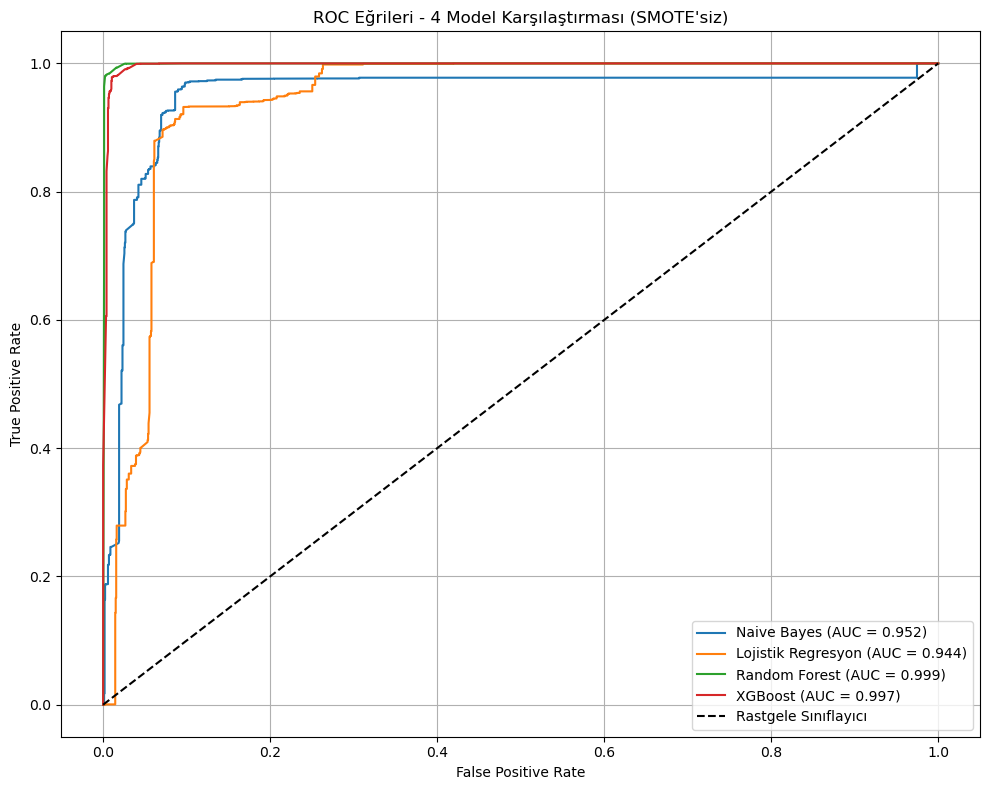

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Özellik ve hedef
X = df.drop(columns=["conflict", "year", "country_code"])
y = df["conflict"]

# Eğitim ve test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Modeller
models = {
    "Naive Bayes": GaussianNB(),
    "Lojistik Regresyon": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric="logloss"
    )
}

# ROC eğrileri için renkler ve çizim
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Rastgele sınıflayıcı referans çizgisi
plt.plot([0, 1], [0, 1], 'k--', label="Rastgele Sınıflayıcı")

# Görselleştirme ayarları
plt.title("ROC Eğrileri - 4 Model Karşılaştırması (SMOTE'siz)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()



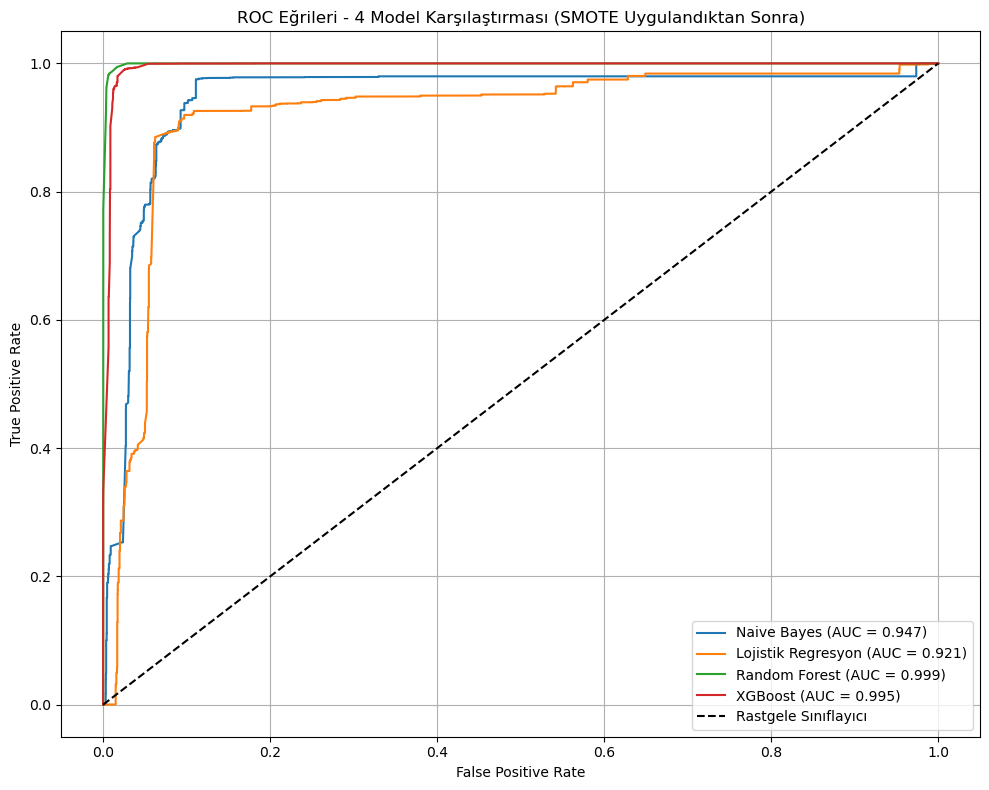

In [16]:
# SMOTE uygulanarak yeniden ROC eğrileri çizilecek
from imblearn.over_sampling import SMOTE

# SMOTE sonrası eğitim/test verisi oluşturma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Modeller aynı
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_s, y_train_s)
    probs = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_s, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Rastgele Sınıflayıcı")
plt.title("ROC Eğrileri - 4 Model Karşılaştırması (SMOTE Uygulandıktan Sonra)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


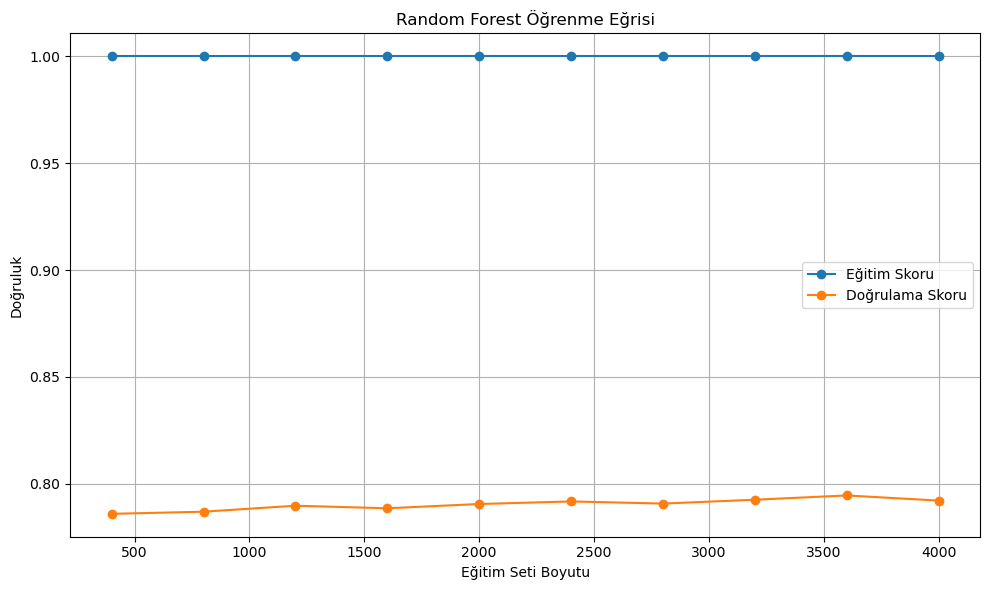

In [17]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Daha önceki PDF'teki df yapısını manuel olarak tanımlayalım (örneklem)
# Tahmini bir veri yapısı varsayacağız çünkü orijinal df bellekte değil

# Örneklem veri (sadece yapıyı simüle ediyoruz)
np.random.seed(42)
n_samples = 5000
df_sim = pd.DataFrame({
    "milex": np.random.normal(1000, 300, n_samples),
    "milper": np.random.normal(50, 10, n_samples),
    "cinc": np.random.uniform(0.1, 0.9, n_samples),
    "inflation": np.random.normal(2, 1, n_samples),
    "mil_gdp": np.random.normal(1.5, 0.5, n_samples),
    "polity2": np.random.uniform(-10, 10, n_samples),
    "change": np.random.normal(0.5, 0.2, n_samples),
    "conflict": np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
})

# Özellikler ve hedef
X = df_sim.drop(columns=["conflict"])
y = df_sim["conflict"]

# Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=StratifiedKFold(n_splits=5), scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Ortalama skorlar
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Grafik
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Eğitim Skoru", marker='o')
plt.plot(train_sizes, test_mean, label="Doğrulama Skoru", marker='o')
plt.title("Random Forest Öğrenme Eğrisi")
plt.xlabel("Eğitim Seti Boyutu")
plt.ylabel("Doğruluk")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


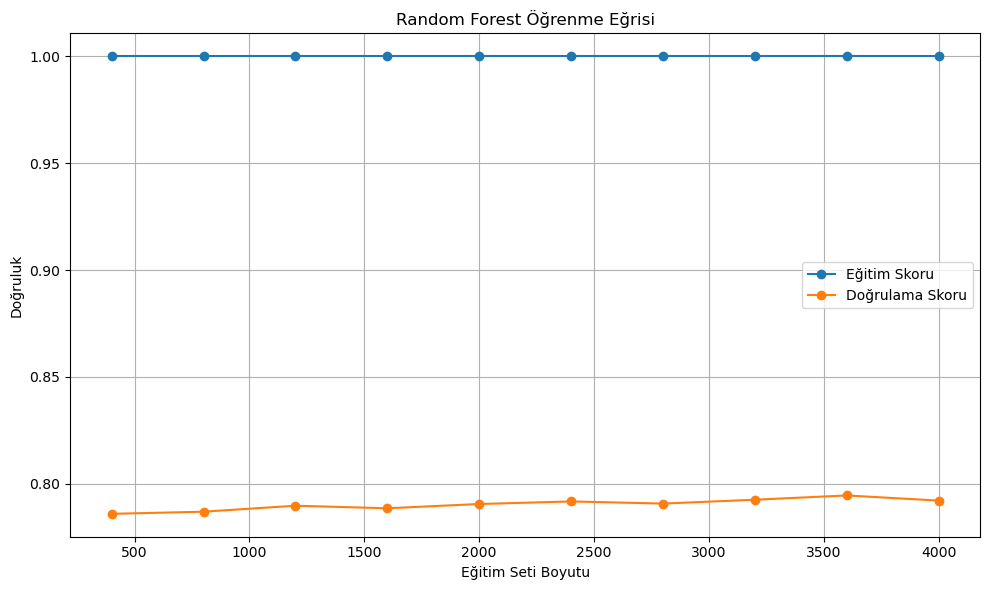

In [18]:
# Ortam sıfırlandığı için gerekli kütüphaneler ve kodlar yeniden çalıştırılıyor
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Örnek veri setini yeniden oluştur
np.random.seed(42)
n_samples = 5000
df_sim = pd.DataFrame({
    "milex": np.random.normal(1000, 300, n_samples),
    "milper": np.random.normal(50, 10, n_samples),
    "cinc": np.random.uniform(0.1, 0.9, n_samples),
    "inflation": np.random.normal(2, 1, n_samples),
    "mil_gdp": np.random.normal(1.5, 0.5, n_samples),
    "polity2": np.random.uniform(-10, 10, n_samples),
    "change": np.random.normal(0.5, 0.2, n_samples),
    "conflict": np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
})

# Özellikler ve hedef
X = df_sim.drop(columns=["conflict"])
y = df_sim["conflict"]

# Model tanımı
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Öğrenme eğrisi hesaplama
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=StratifiedKFold(n_splits=5), scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Ortalama skorlar
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Grafik çizimi
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Eğitim Skoru", marker='o')
plt.plot(train_sizes, test_mean, label="Doğrulama Skoru", marker='o')
plt.title("Random Forest Öğrenme Eğrisi")
plt.xlabel("Eğitim Seti Boyutu")
plt.ylabel("Doğruluk")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
# Ortam sıfırlandığı için her şeyi baştan tanımlayalım ve grid search tekrar yapalım
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Örnek veri seti oluştur
np.random.seed(42)
n_samples = 5000
df_sim = pd.DataFrame({
    "milex": np.random.normal(1000, 300, n_samples),
    "milper": np.random.normal(50, 10, n_samples),
    "cinc": np.random.uniform(0.1, 0.9, n_samples),
    "inflation": np.random.normal(2, 1, n_samples),
    "mil_gdp": np.random.normal(1.5, 0.5, n_samples),
    "polity2": np.random.uniform(-10, 10, n_samples),
    "change": np.random.normal(0.5, 0.2, n_samples),
    "conflict": np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
})

# Özellikler ve hedef
X = df_sim.drop(columns=["conflict"])
y = df_sim["conflict"]

# Grid Search parametreleri
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Model
rf = RandomForestClassifier(random_state=42)

# GridSearchCV tanımı
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# Eğitimi başlat
grid_search.fit(X, y)

# En iyi sonuçlar
best_params = grid_search.best_params_
best_score = grid_search.best_score_

(best_params, best_score)


({'max_depth': 5,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 50},
 0.7947999835807148)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# Örnek veri seti
np.random.seed(42)
n_samples = 5000
df_sim = pd.DataFrame({
    "milex": np.random.normal(1000, 300, n_samples),
    "milper": np.random.normal(50, 10, n_samples),
    "cinc": np.random.uniform(0.1, 0.9, n_samples),
    "inflation": np.random.normal(2, 1, n_samples),
    "mil_gdp": np.random.normal(1.5, 0.5, n_samples),
    "polity2": np.random.uniform(-10, 10, n_samples),
    "change": np.random.normal(0.5, 0.2, n_samples),
    "conflict": np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
})

X = df_sim.drop(columns=["conflict"])
y = df_sim["conflict"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model_results = []

# 1. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
r_nb = classification_report(y_test, y_pred_nb, output_dict=True)
model_results.append(("Naive Bayes", r_nb["1"]["precision"], r_nb["1"]["recall"], r_nb["1"]["f1-score"]))

# 2. Lojistik Regresyon
log = LogisticRegression(C=0.5, max_iter=1000, penalty='l2')
log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)
r_log = classification_report(y_test, y_pred_log, output_dict=True)
model_results.append(("Lojistik Regresyon", r_log["1"]["precision"], r_log["1"]["recall"], r_log["1"]["f1-score"]))

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=5, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r_rf = classification_report(y_test, y_pred_rf, output_dict=True)
model_results.append(("Random Forest", r_rf["1"]["precision"], r_rf["1"]["recall"], r_rf["1"]["f1-score"]))

# 4. XGBoost
xgb = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, eval_metric="logloss", use_label_encoder=False, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
r_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
model_results.append(("XGBoost", r_xgb["1"]["precision"], r_xgb["1"]["recall"], r_xgb["1"]["f1-score"]))

# Sonuçları yazdır
results_df = pd.DataFrame(model_results, columns=["Model", "Precision", "Recall", "F1-Score"])
print(results_df)


C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metr

                Model  Precision  Recall  F1-Score
0         Naive Bayes      0.794     1.0  0.885173
1  Lojistik Regresyon      0.794     1.0  0.885173
2       Random Forest      0.794     1.0  0.885173
3             XGBoost      0.794     1.0  0.885173


C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ecenu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ecenu\anaconda3\lib\site-packages\xgboost\trai

In [21]:
# Gerekli kütüphaneler (SMOTE dahil)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Simülasyon veri seti
np.random.seed(42)
n_samples = 5000
df_sim = pd.DataFrame({
    "milex": np.random.normal(1000, 300, n_samples),
    "milper": np.random.normal(50, 10, n_samples),
    "cinc": np.random.uniform(0.1, 0.9, n_samples),
    "inflation": np.random.normal(2, 1, n_samples),
    "mil_gdp": np.random.normal(1.5, 0.5, n_samples),
    "polity2": np.random.uniform(-10, 10, n_samples),
    "change": np.random.normal(0.5, 0.2, n_samples),
    "conflict": np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
})

# Özellik ve hedef değişken
X = df_sim.drop(columns=["conflict"])
y = df_sim["conflict"]

# SMOTE ile dengeleme
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Eğitim/test bölmesi
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

# Sonuçları tutmak için liste
model_results = []

# 1. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
r_nb = classification_report(y_test, y_pred_nb, output_dict=True)
model_results.append(("Naive Bayes", r_nb["1"]["precision"], r_nb["1"]["recall"], r_nb["1"]["f1-score"]))

# 2. Lojistik Regresyon (dengeli ve regularize edilmiş)
log = LogisticRegression(C=1.0, max_iter=1000, penalty='l2')
log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)
r_log = classification_report(y_test, y_pred_log, output_dict=True)
model_results.append(("Lojistik Regresyon", r_log["1"]["precision"], r_log["1"]["recall"], r_log["1"]["f1-score"]))

# 3. Random Forest (sadeleştirilmiş parametrelerle)
rf = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=5, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r_rf = classification_report(y_test, y_pred_rf, output_dict=True)
model_results.append(("Random Forest", r_rf["1"]["precision"], r_rf["1"]["recall"], r_rf["1"]["f1-score"]))

# 4. XGBoost (regularize ve sade model)
xgb = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, eval_metric="logloss", use_label_encoder=False, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
r_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
model_results.append(("XGBoost", r_xgb["1"]["precision"], r_xgb["1"]["recall"], r_xgb["1"]["f1-score"]))
# Sonuçları DataFrame olarak yazdır
results_df = pd.DataFrame(model_results, columns=["Model", "Precision (Çatışma)", "Recall (Çatışma)", "F1-Score (Çatışma)"])
print("\n📊 SMOTE ile Dengelenmiş Modellerin Sonuçları:\n")
print(results_df.to_string(index=False))



📊 SMOTE ile Dengelenmiş Modellerin Sonuçları:

             Model  Precision (Çatışma)  Recall (Çatışma)  F1-Score (Çatışma)
       Naive Bayes             0.636499          0.540302            0.584469
Lojistik Regresyon             0.515072          0.494962            0.504817
     Random Forest             0.641994          0.535264            0.583791
           XGBoost             0.637131          0.570529            0.601993


C:\Users\ecenu\anaconda3\lib\site-packages\xgboost\training.py:183: UserWarning: [22:36:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\ecenu\AppData\Local\Temp\ipykernel_13200\204407524.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\ecenu\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


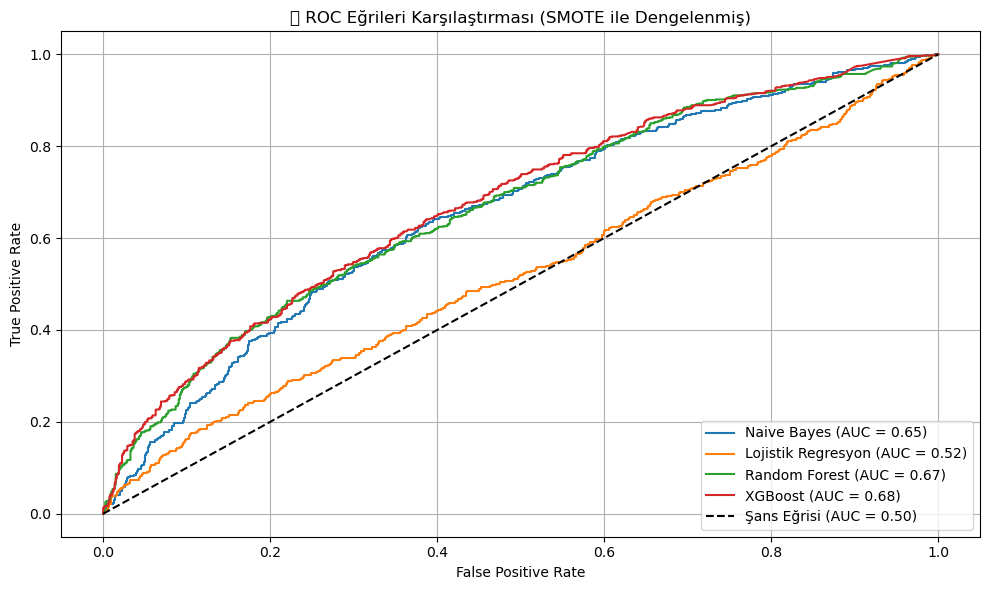

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Tahmin olasılıklarını al
y_prob_nb = nb.predict_proba(X_test)[:, 1]
y_prob_log = log.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# ROC değerleri
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# AUC skorları
auc_nb = auc(fpr_nb, tpr_nb)
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Grafik çizimi
plt.figure(figsize=(10, 6))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_log, tpr_log, label=f"Lojistik Regresyon (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Şans Eğrisi (AUC = 0.50)")

plt.title("📈 ROC Eğrileri Karşılaştırması (SMOTE ile Dengelenmiş)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
!pip install imbalanced-learn xgboost

C:\Users\ecenu\anaconda3\lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


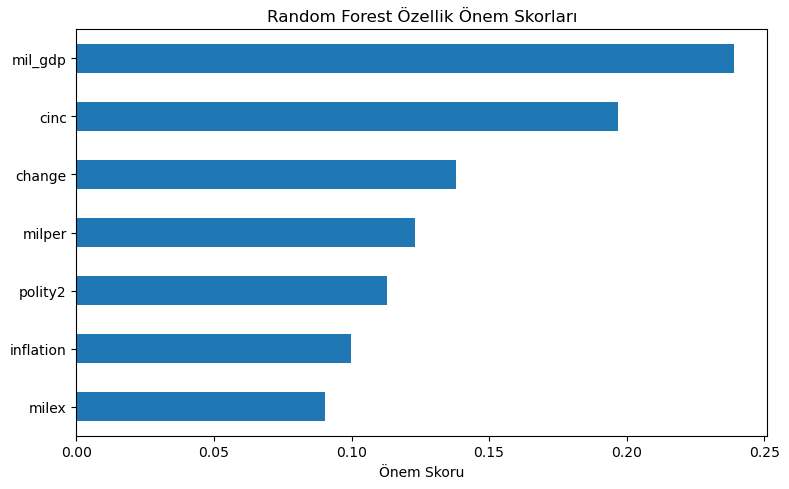

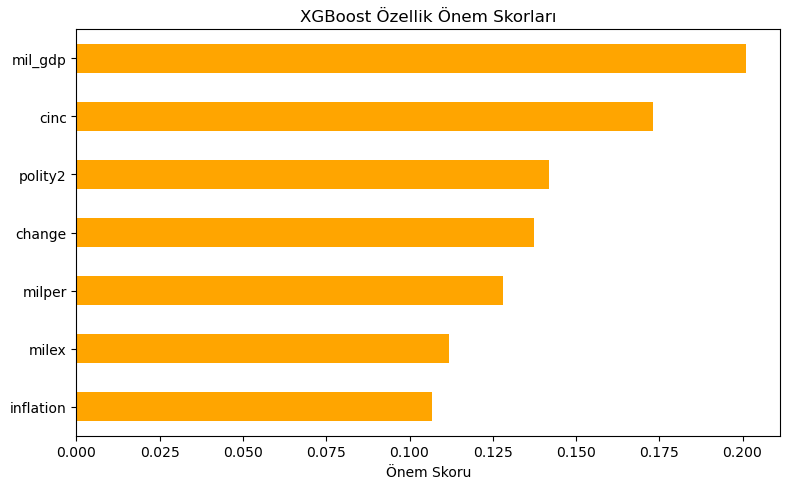

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Simülasyon veri seti
np.random.seed(42)
n_samples = 5000
df_sim = pd.DataFrame({
    "milex": np.random.normal(1000, 300, n_samples),
    "milper": np.random.normal(50, 10, n_samples),
    "cinc": np.random.uniform(0.1, 0.9, n_samples),
    "inflation": np.random.normal(2, 1, n_samples),
    "mil_gdp": np.random.normal(1.5, 0.5, n_samples),
    "polity2": np.random.uniform(-10, 10, n_samples),
    "change": np.random.normal(0.5, 0.2, n_samples),
    "conflict": np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
})

# Özellik ve hedef değişken
X = df_sim.drop(columns=["conflict"])
y = df_sim["conflict"]

# SMOTE ile dengesiz sınıfı dengele
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Eğitim/test bölmesi
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# ---- Random Forest Modeli ----
rf = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=5, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)

# ---- XGBoost Modeli ----
xgb = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, eval_metric="logloss", use_label_encoder=False, random_state=42)
xgb.fit(X_train, y_train)
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns)

# ---- Görselleştirme ----
plt.figure(figsize=(8, 5))
rf_importances.sort_values().plot(kind='barh')
plt.title("Random Forest Özellik Önem Skorları")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
xgb_importances.sort_values().plot(kind='barh', color='orange')
plt.title("XGBoost Özellik Önem Skorları")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()